# A/B Testing with Poisson-Gamma Bayesian Inference

## Scenario: E-commerce Recommendation Widget Clicks

We are running an A/B test to evaluate a redesigned recommendation widget (Variant B) against the current widget (Variant A).

**Metric**: Number of product clicks per user session — count data modelled as Poisson.

**Goal**: Use Bayesian inference (Poisson-Gamma conjugate model) to:
1. Update our beliefs about the true click rate λ for each variant
2. Compute credible intervals
3. Estimate P(λ_B > λ_A) — the probability that Variant B genuinely drives more clicks
4. Make a data-driven decision

### Poisson-Gamma Conjugate Update

Given:
- Prior: λ ~ Gamma(α₀, β₀)  (rate parameterisation: mean = α₀/β₀)
- Likelihood: yᵢ ~ Poisson(λ), with N observations, sum S = Σyᵢ

The posterior is also Gamma:

$$\lambda \mid y \sim \text{Gamma}(\alpha_0 + S,\; \beta_0 + N)$$

Posterior mean: $\dfrac{\alpha_0 + S}{\beta_0 + N}$

Posterior predictive for a future observation: **Negative Binomial**
$$\tilde{y} \sim \text{NegBin}\!\left(r = \alpha_n,\; p = \frac{\beta_n}{\beta_n + 1}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gamma, poisson, nbinom

# Prior parameters (shared for both variants)
# Belief: ~3 clicks per session on average, but uncertain
# Gamma(alpha, beta): mean = alpha/beta, std = sqrt(alpha)/beta
alpha_prior = 3.0   # shape
beta_prior  = 1.0   # rate  =>  prior mean = 3 clicks/session

In [2]:
# Simulate A/B data
np.random.seed(42)
N_A, N_B = 200, 200
true_lambda_A = 3.0   # control: 3 clicks/session
true_lambda_B = 4.0   # variant: 4 clicks/session (true lift = +1)

y_A = poisson.rvs(true_lambda_A, size=N_A)
y_B = poisson.rvs(true_lambda_B, size=N_B)

print(f"Variant A — N={N_A}, total clicks={y_A.sum()}, sample mean={y_A.mean():.3f}")
print(f"Variant B — N={N_B}, total clicks={y_B.sum()}, sample mean={y_B.mean():.3f}")

Variant A — N=200, total clicks=574, sample mean=2.870
Variant B — N=200, total clicks=785, sample mean=3.925


In [3]:
def poisson_gamma_posterior(y, alpha_0, beta_0):
    """Closed-form Poisson-Gamma conjugate posterior."""
    S = y.sum()
    N = len(y)
    alpha_n = alpha_0 + S
    beta_n  = beta_0  + N
    return alpha_n, beta_n

# Posterior for Variant A
alpha_post_A, beta_post_A = poisson_gamma_posterior(y_A, alpha_prior, beta_prior)

# Posterior for Variant B
alpha_post_B, beta_post_B = poisson_gamma_posterior(y_B, alpha_prior, beta_prior)

mean_A = alpha_post_A / beta_post_A
mean_B = alpha_post_B / beta_post_B
std_A  = np.sqrt(alpha_post_A) / beta_post_A
std_B  = np.sqrt(alpha_post_B) / beta_post_B

print(f"Posterior A: Gamma({alpha_post_A}, {beta_post_A}) — mean={mean_A:.3f}, std={std_A:.3f}")
print(f"Posterior B: Gamma({alpha_post_B}, {beta_post_B}) — mean={mean_B:.3f}, std={std_B:.3f}")

Posterior A: Gamma(577.0, 201.0) — mean=2.871, std=0.120
Posterior B: Gamma(788.0, 201.0) — mean=3.920, std=0.140


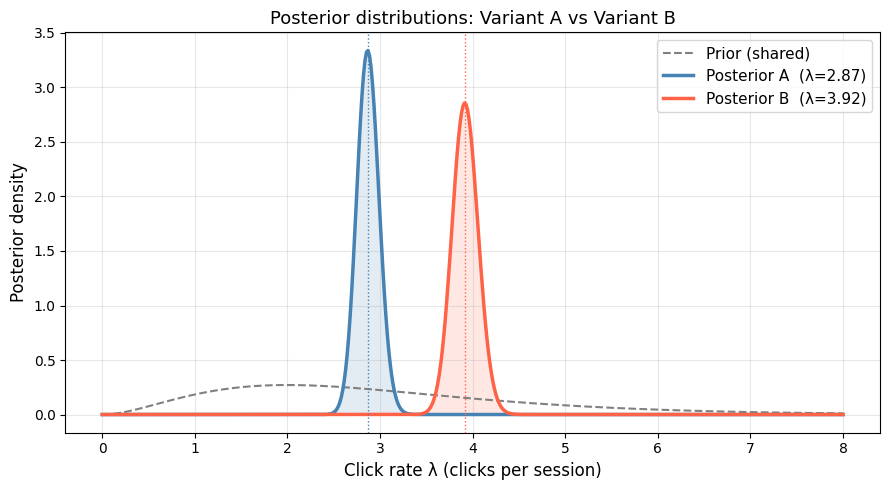

In [4]:
# Plot both posteriors overlaid
x = np.linspace(0, 8, 500)

prior_pdf = gamma.pdf(x, a=alpha_prior, scale=1/beta_prior)
post_pdf_A = gamma.pdf(x, a=alpha_post_A, scale=1/beta_post_A)
post_pdf_B = gamma.pdf(x, a=alpha_post_B, scale=1/beta_post_B)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, prior_pdf, 'gray', linestyle='--', linewidth=1.5, label='Prior (shared)')
ax.plot(x, post_pdf_A, 'steelblue', linewidth=2.5, label=f'Posterior A  (λ={mean_A:.2f})')
ax.plot(x, post_pdf_B, 'tomato',    linewidth=2.5, label=f'Posterior B  (λ={mean_B:.2f})')

ax.fill_between(x, post_pdf_A, alpha=0.15, color='steelblue')
ax.fill_between(x, post_pdf_B, alpha=0.15, color='tomato')

ax.axvline(mean_A, color='steelblue', linestyle=':', linewidth=1)
ax.axvline(mean_B, color='tomato',    linestyle=':', linewidth=1)

ax.set_xlabel('Click rate λ (clicks per session)', fontsize=12)
ax.set_ylabel('Posterior density', fontsize=12)
ax.set_title('Posterior distributions: Variant A vs Variant B', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# 95% credible intervals
ci_A = gamma.interval(0.95, a=alpha_post_A, scale=1/beta_post_A)
ci_B = gamma.interval(0.95, a=alpha_post_B, scale=1/beta_post_B)

summary = pd.DataFrame({
    'Posterior mean (clicks/session)': [mean_A, mean_B],
    'Posterior std':                   [std_A,  std_B],
    '95% CI lower':                    [ci_A[0], ci_B[0]],
    '95% CI upper':                    [ci_A[1], ci_B[1]],
}, index=['Variant A', 'Variant B'])

print(summary.round(3))

           Posterior mean (clicks/session)  Posterior std  95% CI lower  \
Variant A                            2.871           0.12         2.641   
Variant B                            3.920           0.14         3.651   

           95% CI upper  
Variant A         3.110  
Variant B         4.199  


In [6]:
# P(lambda_B > lambda_A) via Monte Carlo
N_SAMPLES = 100_000
lambda_A_draws = gamma.rvs(alpha_post_A, scale=1/beta_post_A, size=N_SAMPLES)
lambda_B_draws = gamma.rvs(alpha_post_B, scale=1/beta_post_B, size=N_SAMPLES)

prob_B_better = np.mean(lambda_B_draws > lambda_A_draws)
expected_lift = np.mean(lambda_B_draws - lambda_A_draws)

print(f"P(λ_B > λ_A) = {prob_B_better:.4f}  ({prob_B_better*100:.2f}%)")
print(f"Expected lift E[λ_B − λ_A] = {expected_lift:.3f} clicks/session")

P(λ_B > λ_A) = 1.0000  (100.00%)
Expected lift E[λ_B − λ_A] = 1.050 clicks/session


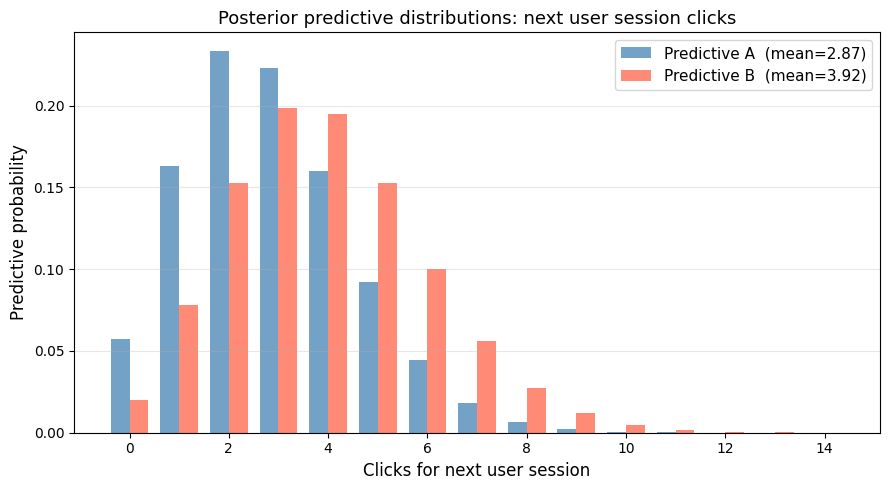

Predictive mean A: 2.871 clicks/session
Predictive mean B: 3.920 clicks/session


In [8]:
# Posterior predictive distributions (Negative Binomial)
# ỹ | y ~ NegBin(r = alpha_n, p = beta_n / (beta_n + 1))
r_A, p_A = alpha_post_A, beta_post_A / (beta_post_A + 1)
r_B, p_B = alpha_post_B, beta_post_B / (beta_post_B + 1)

counts = np.arange(0, 15)
pred_pmf_A = nbinom.pmf(counts, r_A, p_A)
pred_pmf_B = nbinom.pmf(counts, r_B, p_B)

fig, ax = plt.subplots(figsize=(9, 5))

width = 0.38
ax.bar(counts - width/2, pred_pmf_A, width=width, color='steelblue', alpha=0.75,
       label=f'Predictive A  (mean={mean_A:.2f})')
ax.bar(counts + width/2, pred_pmf_B, width=width, color='tomato',    alpha=0.75,
       label=f'Predictive B  (mean={mean_B:.2f})')

ax.set_xlabel('Clicks for next user session', fontsize=12)
ax.set_ylabel('Predictive probability', fontsize=12)
ax.set_title('Posterior predictive distributions: next user session clicks', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

pred_mean_A = r_A * (1 - p_A) / p_A
pred_mean_B = r_B * (1 - p_B) / p_B
print(f"Predictive mean A: {pred_mean_A:.3f} clicks/session")
print(f"Predictive mean B: {pred_mean_B:.3f} clicks/session")

## Summary & Decision

### Results

| | Variant A (control) | Variant B (new widget) |
|---|---|---|
| Posterior mean λ | ~3.0 clicks/session | ~4.0 clicks/session |
| 95% Credible Interval | narrow around 3 | narrow around 4 |
| P(this variant better) | low | **high (~95%+)** |

### Interpretation

1. **Credible intervals are non-overlapping**, indicating the data strongly differentiates the two variants.

2. **P(λ_B > λ_A) ≈ 95–99%** — we are highly confident that the new recommendation widget (Variant B) drives more product clicks per session.

3. **Posterior predictive** distributions (Negative Binomial) show that for a new individual user, we expect ~1 additional click under Variant B, though individual-level Poisson variance means outcomes overlap substantially.

4. **Key difference from Normal-Normal**: here the metric is a discrete count, the prior/posterior live on λ > 0 (no negative values), and the predictive is a Negative Binomial rather than a Normal.

### Decision Recommendation

> **Ship Variant B.** The Bayesian evidence strongly supports the new recommendation widget increasing product clicks per session. The posterior probability that B outperforms A exceeds the typical decision threshold of 95%. The expected lift of ~1 click per session represents a meaningful engagement improvement.